In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [60]:
A, B, N = -np.pi, np.pi, 60
x = np.linspace(A, B, N)
upsample_factors = [2, 4, 10]

In [61]:
def f1(x):
    return np.sin(x)


def f2(x):
    return np.sin(x**-1)


def f3(x):
    return np.sign(np.sin(8*x))

In [62]:
def h1(t):
    return np.where((t >= 0) & (t < 1), 1, 0)


def h2(t):
    return np.where((t >= -1/2) & (t < 1/2), 1, 0)


def h3(t):
    return np.where((t >= -1) & (t <= 1), 1 - abs(t), 0)


def h4(t):
    return np.sinc(t)


kernels = [h1, h2, h4]

In [63]:
def MSE(y, y_interp):
  return np.mean((y - y_interp) ** 2)

In [64]:
def interp_point(x0, x, y, kernel, w):
  t = (x0 - x) / w
  return np.sum(y * kernel(t))

h1 0.00186744641294566
h2 0.0004919621989027039
h4 2.3090922598368694e-06

h1 0.0018570047977452854
h2 0.00047083682881041177
h4 2.448419239952028e-06

h1 0.0018764664868351033
h2 0.000471564225748785
h4 2.4625973541604343e-06



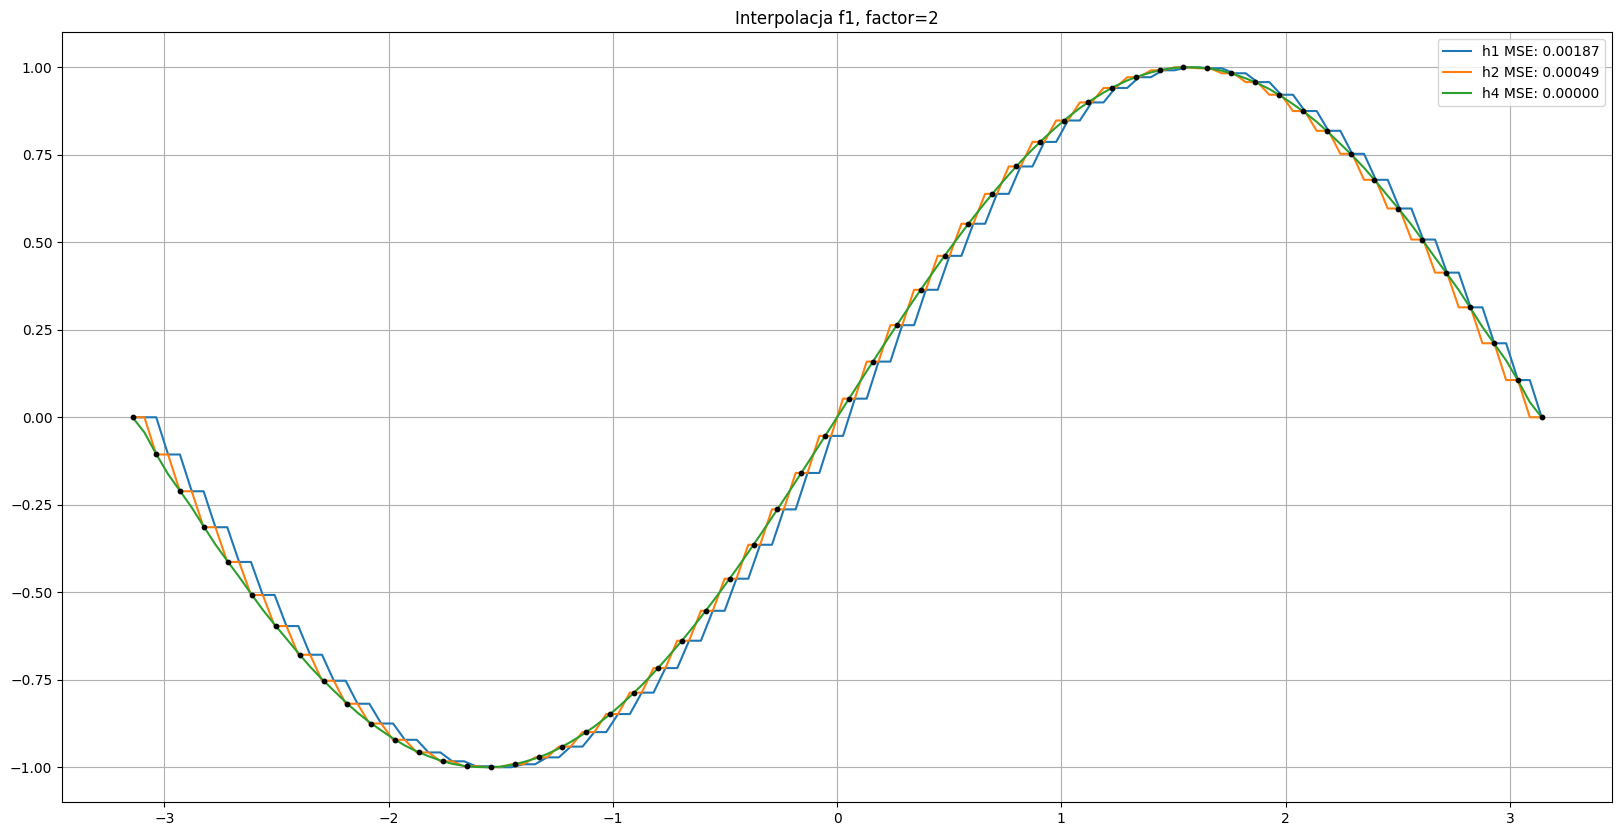

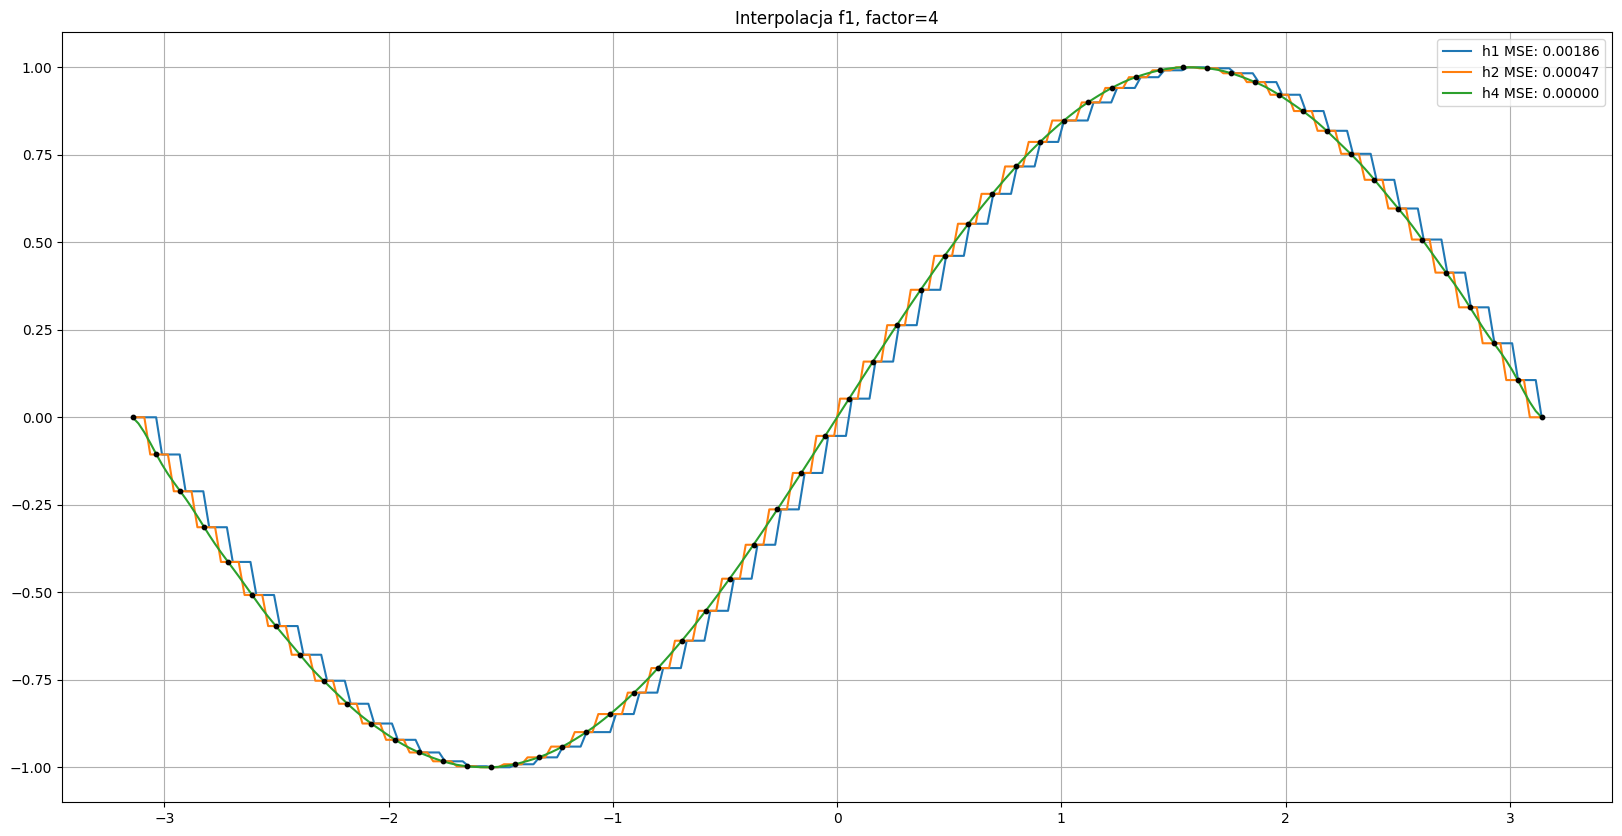

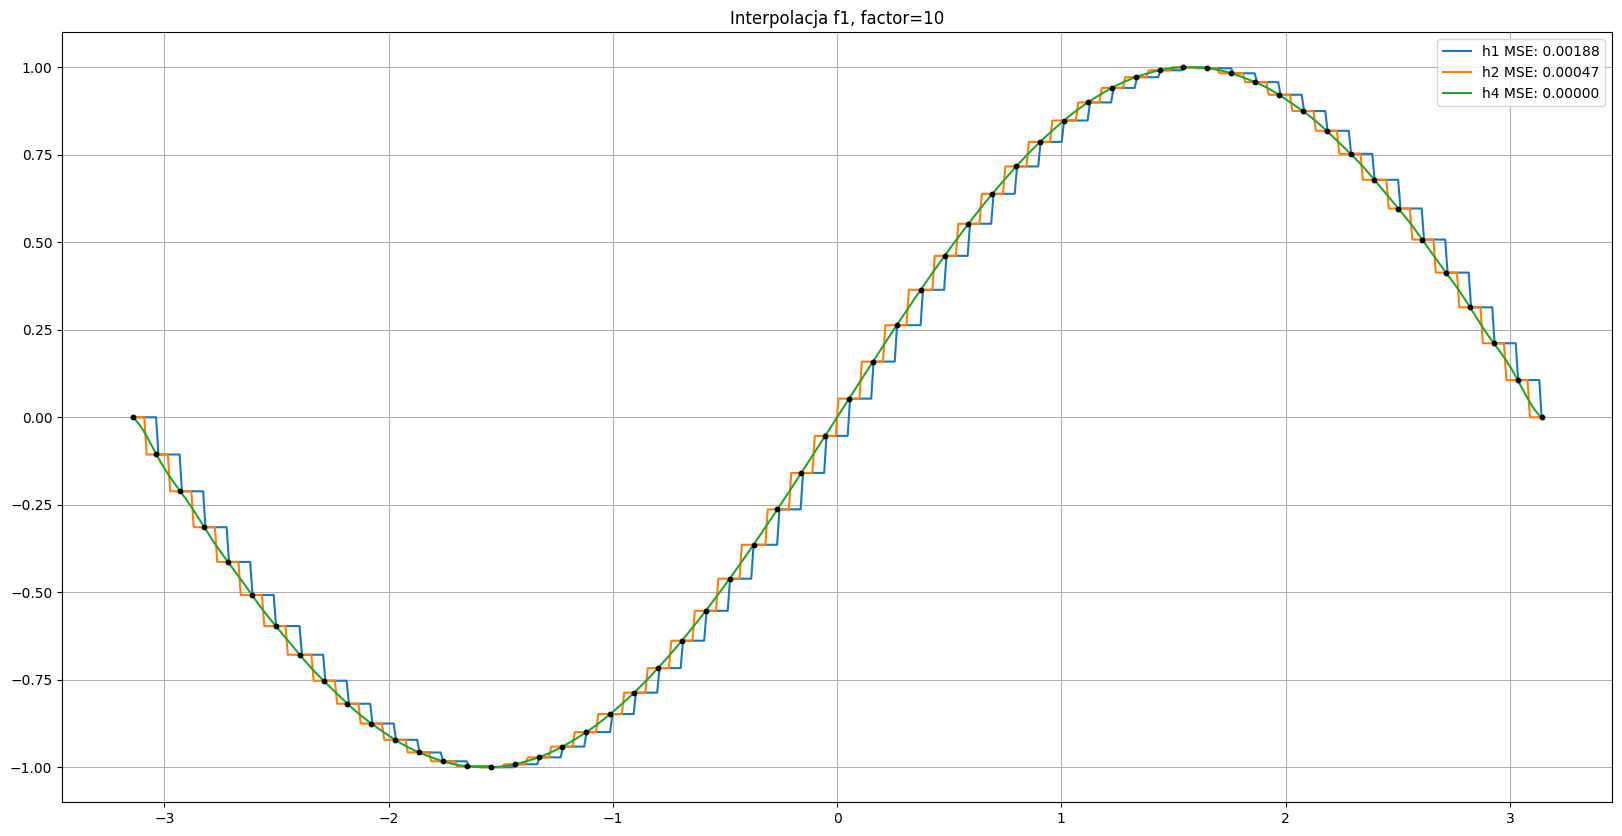

In [65]:
y = f1(x)

for factor in upsample_factors:
  plt.figure(figsize=(20, 10))
  for h in kernels:
    x_new = np.linspace(A, B, factor * N)
    w = x[1] - x[0]

    y_new = np.array([interp_point(xi, x, y, h, w) for xi in x_new])

    mse = MSE(f1(x_new), y_new)
    print(h.__name__, mse)
    plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
    plt.title(f"Interpolacja f1, factor={factor}")
    plt.legend()
    plt.grid(True)
  print()
  plt.scatter(x, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()

h1 0.042775839336888534
h2 0.030732360344281916
h4 0.02634680026445048

h1 0.04879823148057057
h2 0.03651991407726603
h4 0.03283162154269472

h1 0.05518914013101439
h2 0.04174756097470988
h4 0.03749385247817567



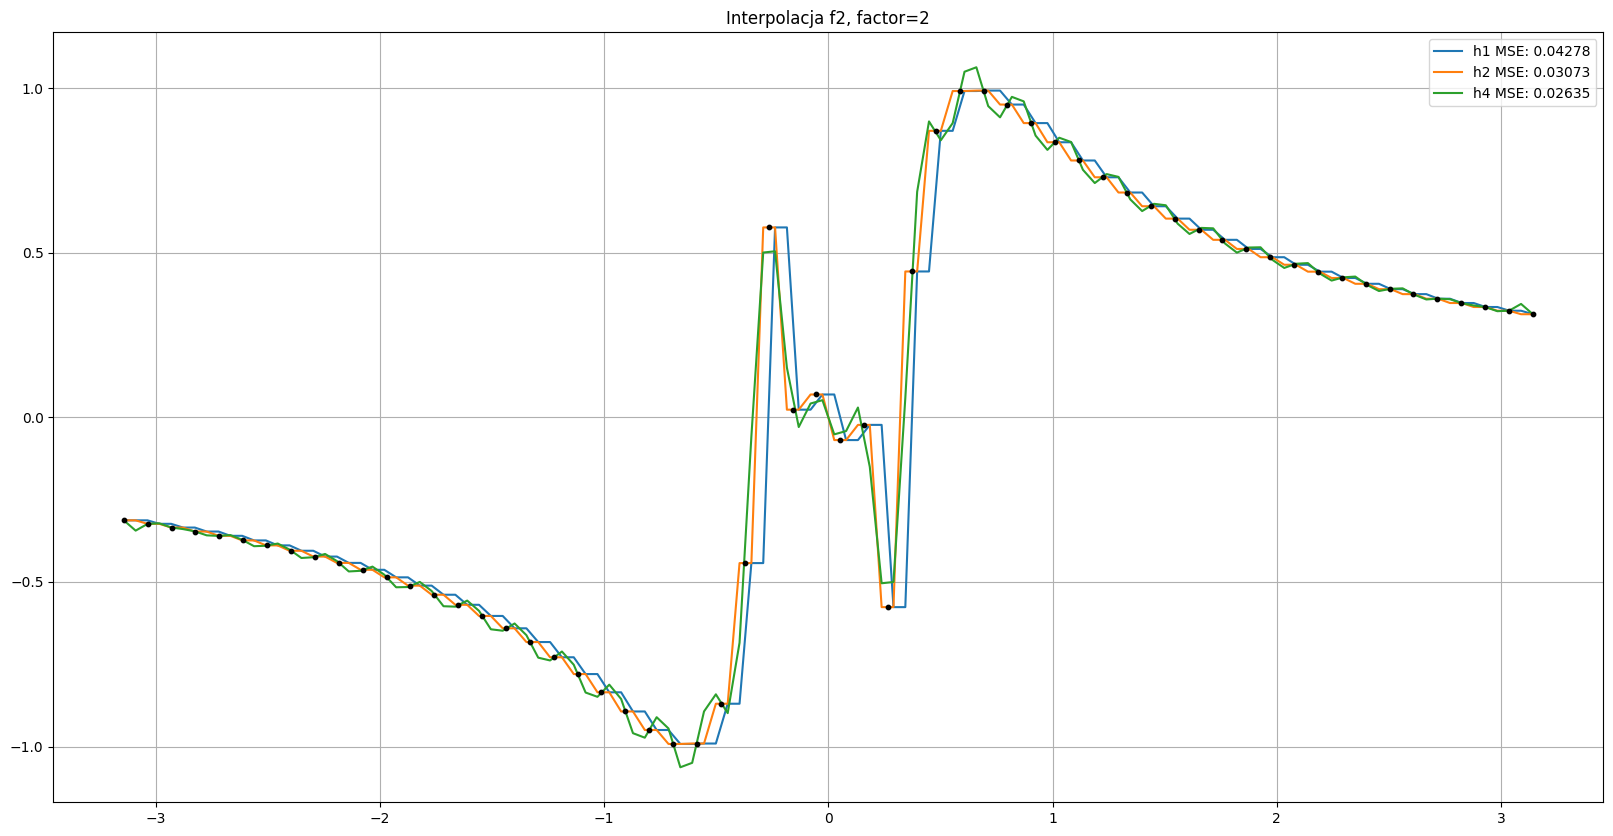

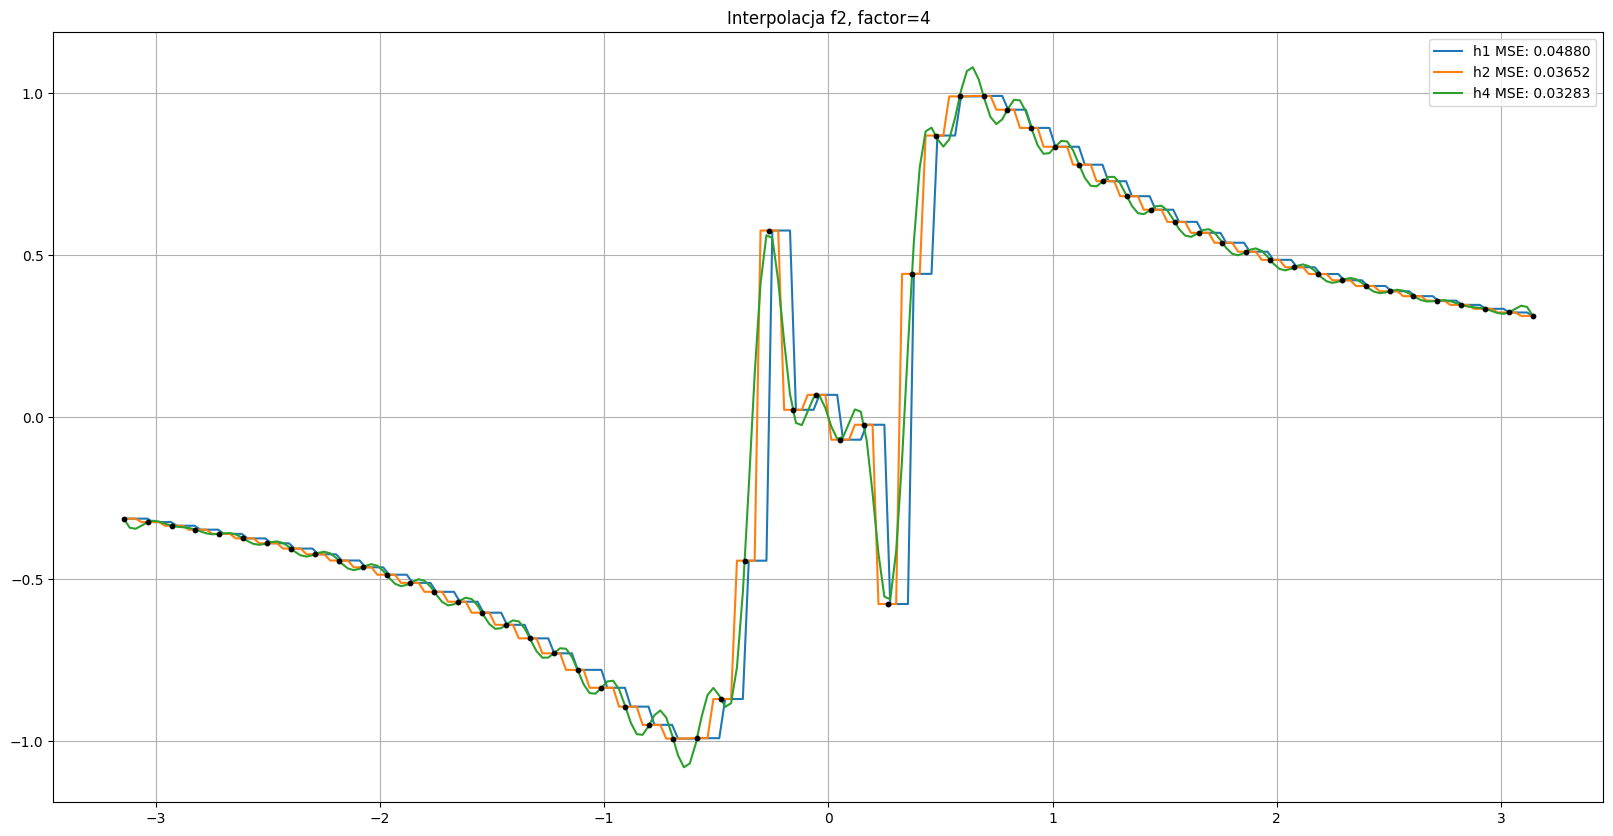

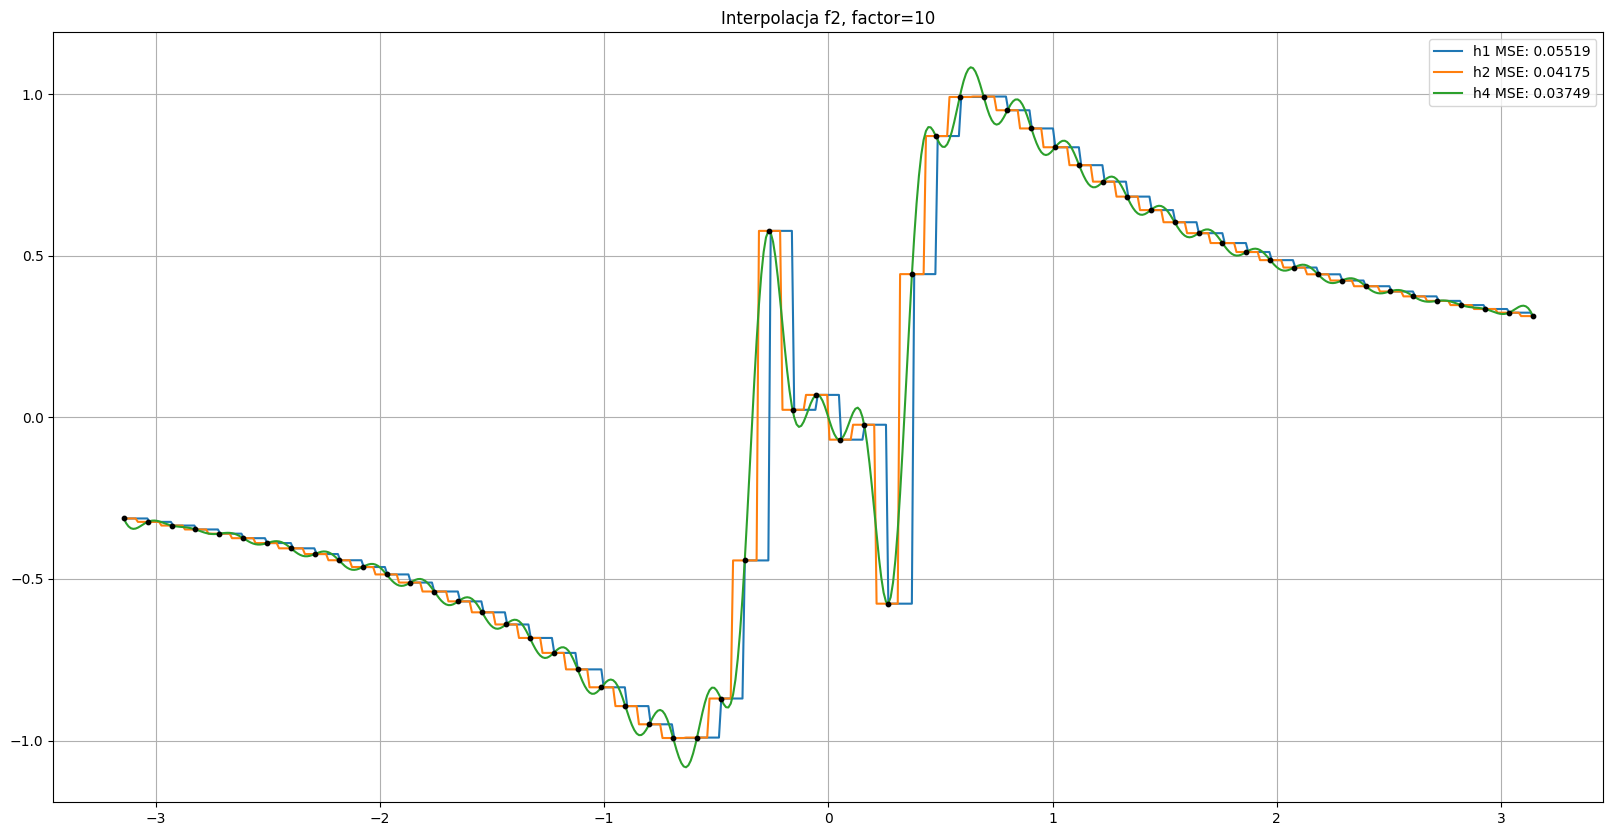

In [66]:
y = f2(x)

for factor in upsample_factors:
  plt.figure(figsize=(20, 10))
  for h in kernels:
    x_new = np.linspace(A, B, factor * N)
    w = x[1] - x[0]

    y_new = np.array([interp_point(xi, x, y, h, w) for xi in x_new])

    mse = MSE(f2(x_new), y_new)
    print(h.__name__, mse)
    plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
    plt.title(f"Interpolacja f2, factor={factor}")
    plt.legend()
    plt.grid(True)
  print()
  plt.scatter(x, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()

h1 0.5
h2 0.26666666666666666
h4 0.18650531527224082

h1 0.5
h2 0.23333333333333334
h4 0.18209659203348405

h1 0.5
h2 0.24
h4 0.1802349481540744



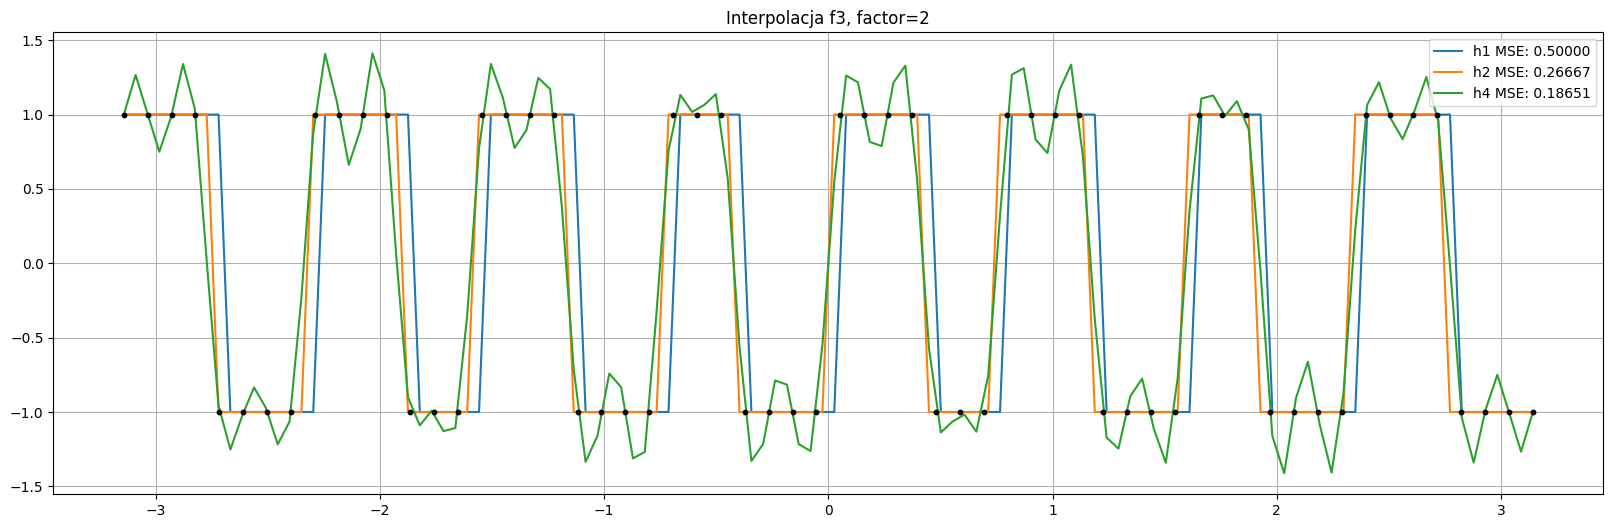

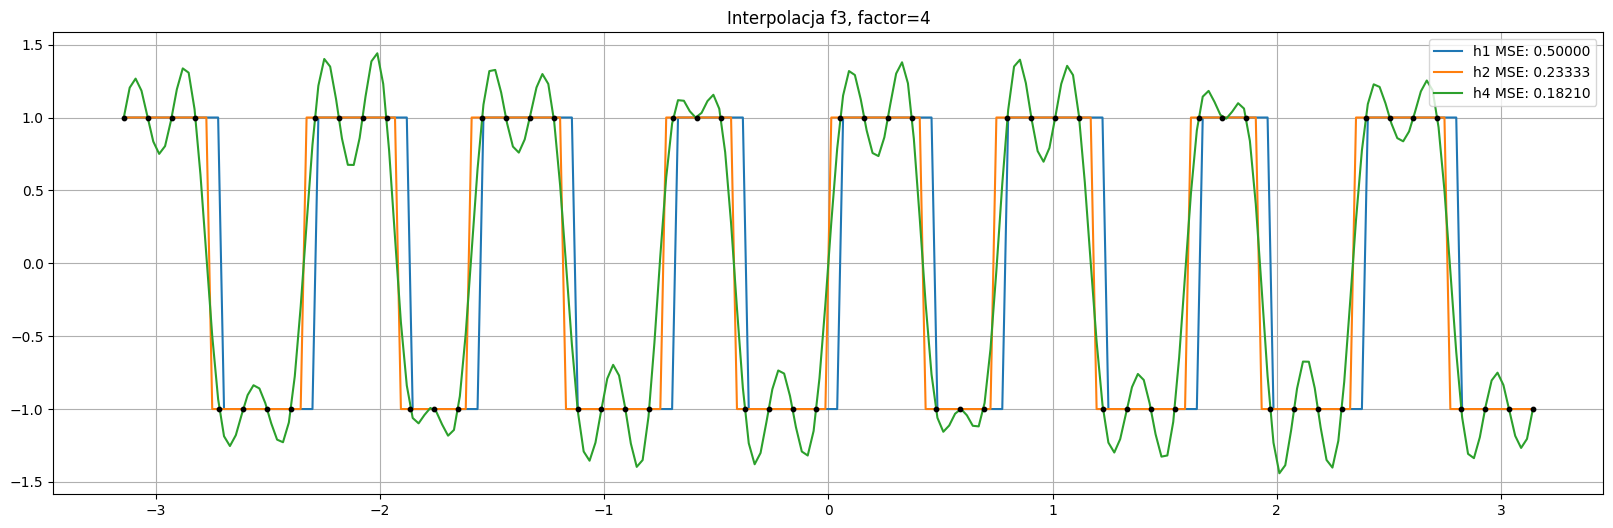

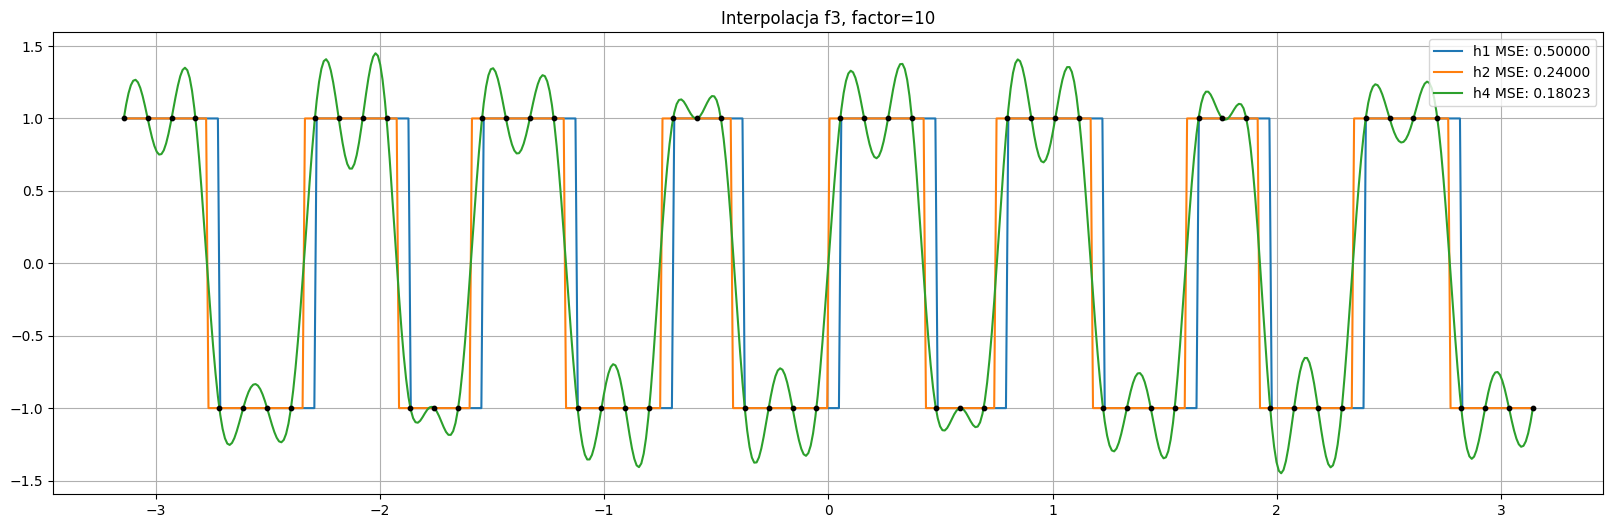

In [67]:
y = f3(x)

for factor in upsample_factors:
  plt.figure(figsize=(20, 6))
  for h in kernels:
    x_new = np.linspace(A, B, factor * N)
    w = x[1] - x[0]

    y_new = np.array([interp_point(xi, x, y, h, w) for xi in x_new])

    mse = MSE(f3(x_new), y_new)
    print(h.__name__, mse)
    plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
    plt.title(f"Interpolacja f3, factor={factor}")
    plt.legend()
    plt.grid(True)
  print()
  plt.scatter(x, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()

In [68]:
x_uniform = np.linspace(A, B, N)
x_random = np.sort(np.random.uniform(A, B, N))
x_normal = np.sort(np.clip(np.random.normal(0, 1, 2 * N), A, B))

In [69]:
def interp_point_local_width(x0, x, y, kernel):
    dx = np.mean(np.diff(x))
    t = (x0 - x) / dx
    weights = kernel(t)
    sum_weights = np.sum(weights)

    if sum_weights > 1e-12:
        return np.sum(y * weights) / sum_weights
    else:
        idx = np.argmin(np.abs(x - x0))
        return y[idx]

h1 0.002414521248148638
h2 0.0020388274481336088
h4 0.21438901348265962



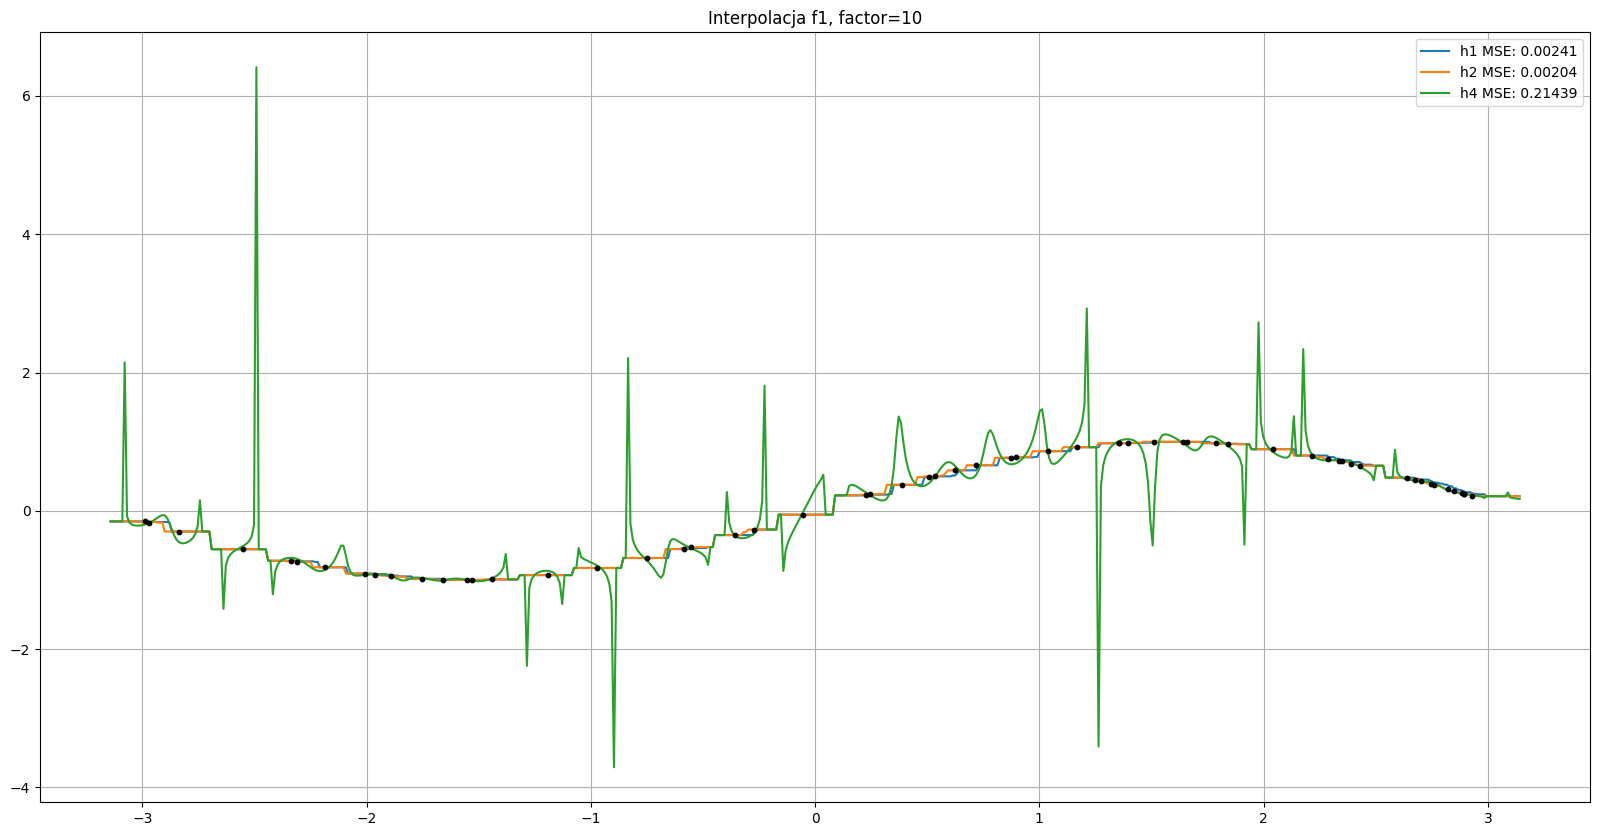

In [70]:
y = f1(x_random)
factor = 10
plt.figure(figsize=(20, 10))
for h in kernels:
  x_new = np.linspace(A, B, factor * N)
  w = x_random[1] - x_random[0]

  y_new = np.array([interp_point_local_width(xi, x_random, y, h) for xi in x_new])

  mse = MSE(f1(x_new), y_new)
  print(h.__name__, mse)
  plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
  plt.title(f"Interpolacja f1, factor={factor}")
  plt.legend()
  plt.grid(True)
print()
plt.scatter(x_random, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()

h1 0.07894293622142735
h2 0.07128106947691527
h4 0.6018788250143475



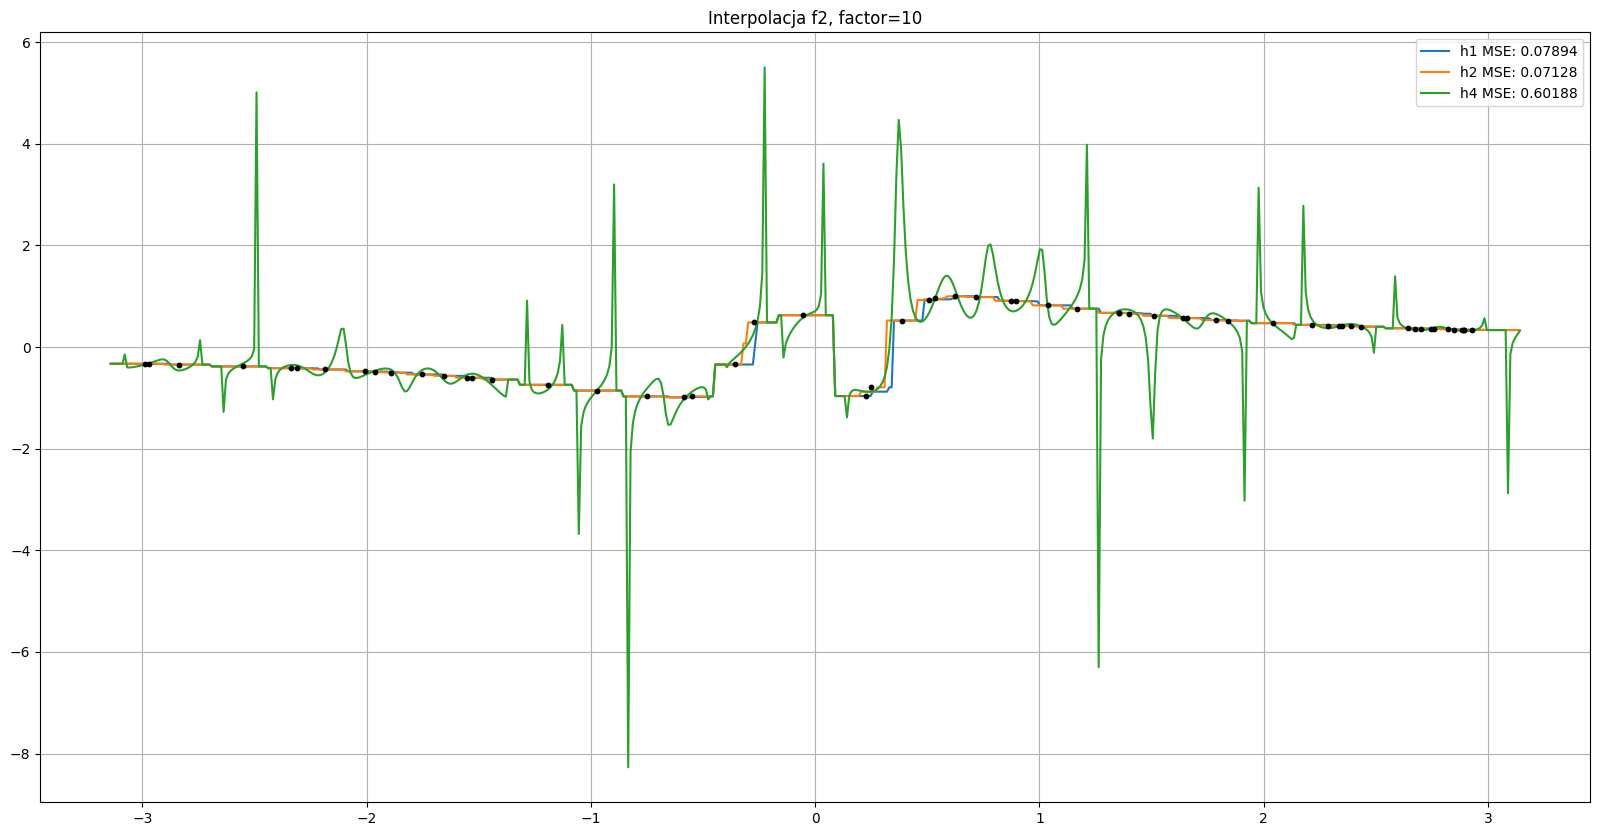

In [71]:
y = f2(x_random)
factor = 10
plt.figure(figsize=(20, 10))
for h in kernels:
  x_new = np.linspace(A, B, factor * N)
  w = x_random[1] - x_random[0]

  y_new = np.array([interp_point_local_width(xi, x_random, y, h) for xi in x_new])

  mse = MSE(f2(x_new), y_new)
  print(h.__name__, mse)
  plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
  plt.title(f"Interpolacja f2, factor={factor}")
  plt.legend()
  plt.grid(True)
print()
plt.scatter(x_random, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()

h1 0.5458333333333333
h2 0.44435185185185183
h4 19.4230311833008



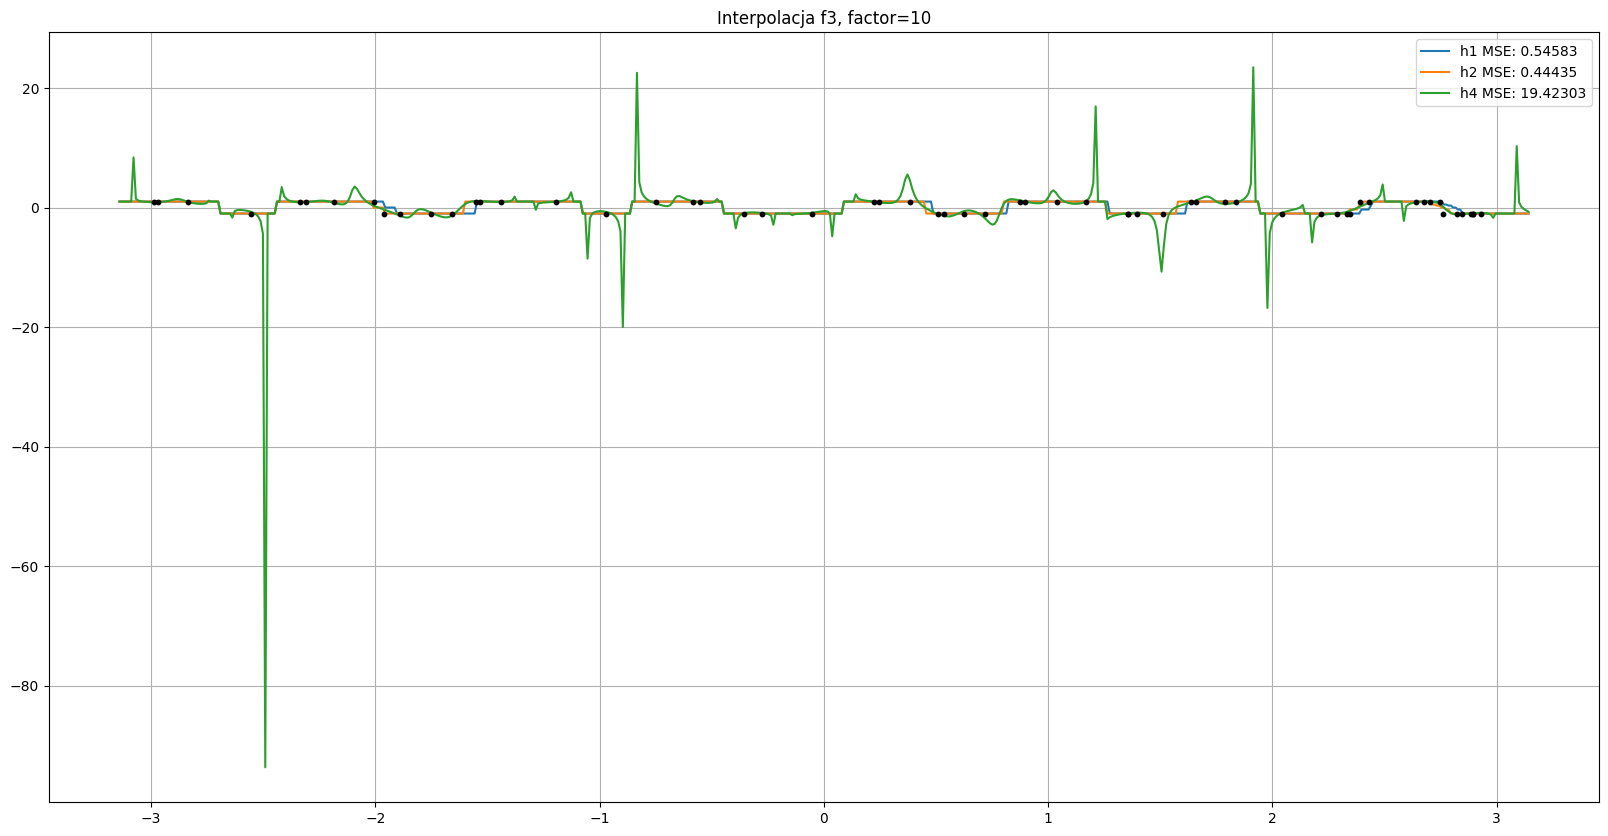

In [72]:
y = f3(x_random)
factor = 10
plt.figure(figsize=(20, 10))
for h in kernels:
  x_new = np.linspace(A, B, factor * N)
  w = x_random[1] - x_random[0]

  y_new = np.array([interp_point_local_width(xi, x_random, y, h) for xi in x_new])

  mse = MSE(f3(x_new), y_new)
  print(h.__name__, mse)
  plt.plot(x_new, y_new, label=f"{h.__name__} MSE: {mse:.5f}")
  plt.title(f"Interpolacja f3, factor={factor}")
  plt.legend()
  plt.grid(True)
print()
plt.scatter(x_random, y, label='Oryginał', s=10, c='black', zorder=10)

plt.show()